In [4]:
from sickle import Sickle
from collections import defaultdict
import csv
from datetime import datetime

# Initialize OAI-PMH connection to arXiv
sickle = Sickle('https://oaipmh.arxiv.org/oai')

print("Fetching AI papers directly from arXiv API...")
print("Both category (cs:cs:AI) and date filters are applied server-side for maximum speed.")

# Applying BOTH category and date filters directly to the server!
api_params = {
    'metadataPrefix': 'arXiv',
    'set': 'cs:cs:AI',  # Fetching ONLY Artificial Intelligence papers directly
    'from': '2016-09-01',
    'until': '2024-01-01'
}

# Fetching records with our highly optimized parameters
records = sickle.ListRecords(**api_params)

daily_counts = defaultdict(int)

# Iterate through the fetched AI records and aggregate daily counts
for record in records:
    data = record.metadata
    
    # Skip the record if it lacks essential metadata
    if not data or "created" not in data:
        continue

    # Extract the creation date
    date_str = data["created"][0]
    
    try:
        # Convert string to date object
        paper_date = datetime.strptime(date_str, "%Y-%m-%d").date()
        daily_counts[str(paper_date)] += 1
    except ValueError:
        # Safely skip records with invalid date formats
        continue 

# Export the aggregated data to a CSV file
with open("ai_daily_papers.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["date", "paper_count"])
    
    # Sort dates chronologically before writing
    for d in sorted(daily_counts):
        writer.writerow([d, daily_counts[d]])

print("Data successfully collected and saved to 'ai_daily_papers.csv'.")

Fetching AI papers directly from arXiv API...
Both category (cs:cs:AI) and date filters are applied server-side for maximum speed.
Data successfully collected and saved to 'ai_daily_papers.csv'.


In [9]:
import pandas as pd

# 1. Load the data and parse the date column as datetime index
df_papers = pd.read_csv("ai_daily_papers.csv", index_col="date", parse_dates=True)

# 2. Filter the data to match the project scope (September 2016 to end of 2023)
df_papers = df_papers.loc["2016-09-01":"2023-12-31"].copy()

# 3. Calculate the default summary statistics (count, mean, std, min, 25%, 50%, 75%, max)
summary_stats_papers = df_papers.describe()

# 4. Calculate and append the variance to the summary statistics
summary_stats_papers.loc['variance'] = df_papers.var()

# 5. Format the float output for better readability (2 decimal places are enough for paper counts)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("--- arXiv AI Papers Daily Dataset Basic Statistical Summary ---")
print(summary_stats_papers)

--- arXiv AI Papers Daily Dataset Basic Statistical Summary ---
          paper_count
count         2665.00
mean            23.32
std             19.41
min              1.00
25%              9.00
50%             17.00
75%             34.00
max            114.00
variance       376.60


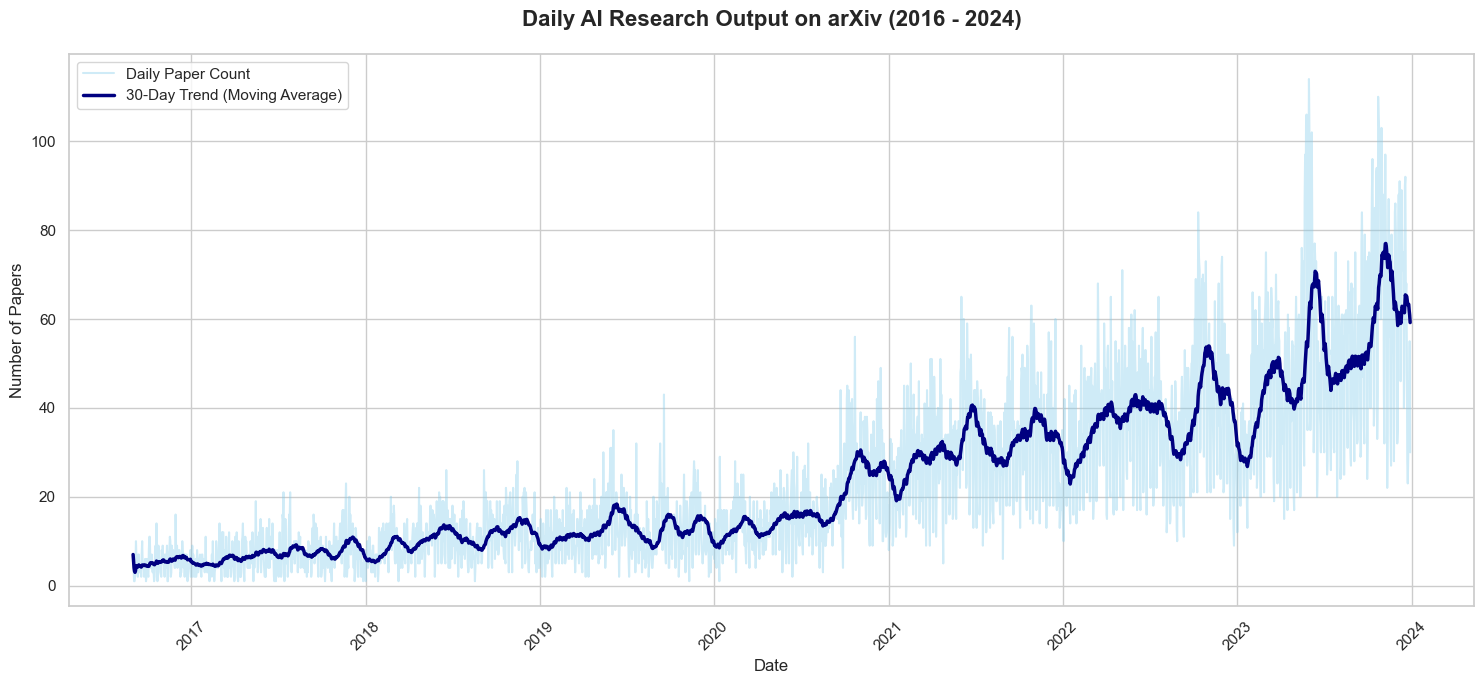

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df_papers = pd.read_csv("ai_daily_papers.csv", parse_dates=["date"])
df_papers.set_index("date", inplace=True)

# 2. Filter to the project's timeframe (2016 to 2024)
df_papers = df_papers.loc["2016-09-01":"2023-12-31"].copy()

# 3. Calculate 30-day moving average to visualize the trend
df_papers["trend_30d"] = df_papers["paper_count"].rolling(window=30, min_periods=1).mean()

# 4. Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 7))

# Plot daily counts with low alpha (faded) to show the raw data distribution
sns.lineplot(data=df_papers, x=df_papers.index, y="paper_count", color="skyblue", alpha=0.4, label="Daily Paper Count")

# Plot the 30-day moving average with a solid line to show the innovation trend
sns.lineplot(data=df_papers, x=df_papers.index, y="trend_30d", color="navy", linewidth=2.5, label="30-Day Trend (Moving Average)")

# Setting titles and labels in English for the report
plt.title("Daily AI Research Output on arXiv (2016 - 2024)", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Papers", fontsize=12)

# Improve x-axis readability
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Show or save the plot
# plt.savefig("arxiv_ai_trend.png", dpi=300)
plt.show()

In [11]:
import pandas as pd

# 1. Load both datasets
df_etf = pd.read_csv("botz_daily_data.csv", parse_dates=["date"])
df_arxiv = pd.read_csv("ai_daily_papers.csv", parse_dates=["date"])

# 2. Sort values to ensure correct alignment
df_etf = df_etf.sort_values("date")
df_arxiv = df_arxiv.sort_values("date")

# 3. Use 'merge_asof' to align each paper date to the NEXT available stock market date
# direction='forward' ensures weekend papers are moved to the next Monday
merged_df = pd.merge_asof(
    df_arxiv, 
    df_etf[['date']], 
    on="date", 
    direction="forward"
)

# 4. Rename the aligned date column and group by it to sum the paper counts
# This step effectively adds weekend/holiday paper counts to the next trading day
final_papers = merged_df.groupby("date")["paper_count"].sum().reset_index()

# 5. Final Merge: Combine the aggregated papers with the ETF financial data
df_final = pd.merge(df_etf, final_papers, on="date", how="left")

# 6. Fill any remaining NaN values (if any) with 0
df_final["paper_count"] = df_final["paper_count"].fillna(0)

# 7. Save the master dataset for analysis
df_final.to_csv("ai_market_master_dataset.csv", index=False)

print("Master dataset successfully created: 'ai_market_master_dataset.csv'")
print(df_final.head(10))

Master dataset successfully created: 'ai_market_master_dataset.csv'
        date  price  daily_return  paper_count
0 2016-09-14  14.17          0.00            3
1 2016-09-15  14.17          0.00            3
2 2016-09-16  14.11         -0.00            3
3 2016-09-19  14.25          0.01            7
4 2016-09-20  14.37          0.01           10
5 2016-09-21  14.37          0.00            5
6 2016-09-22  14.71          0.02            4
7 2016-09-23  14.66         -0.00            5
8 2016-09-26  14.43         -0.02            6
9 2016-09-27  14.60          0.01            6


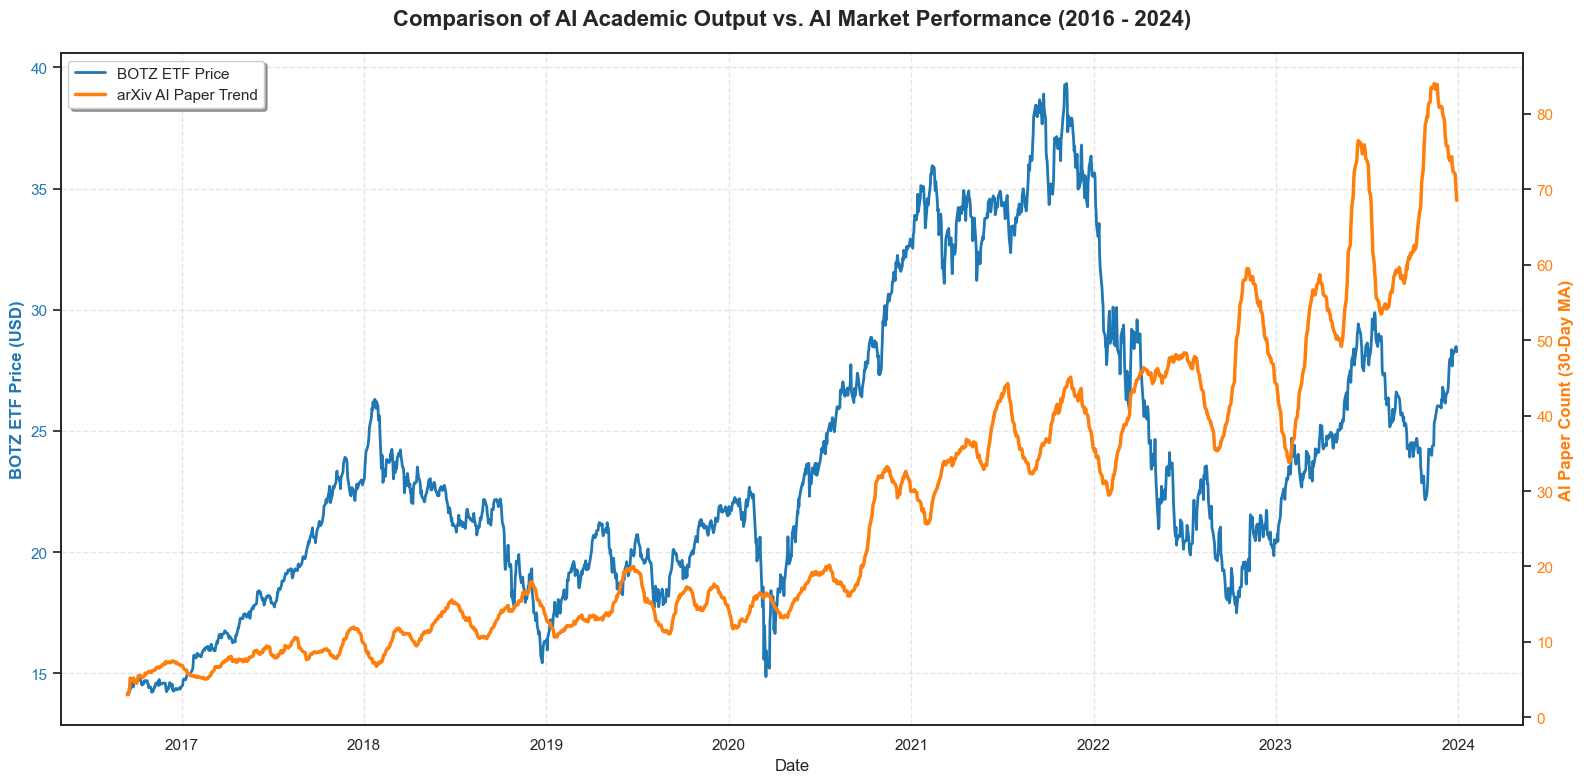

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the merged master dataset
df = pd.read_csv("ai_market_master_dataset.csv", parse_dates=["date"])
df.set_index("date", inplace=True)

# 2. Calculate a 30-day moving average for papers to smooth out the trend
df["paper_trend_30d"] = df["paper_count"].rolling(window=30, min_periods=1).mean()

# 3. Create the plot with dual axes
sns.set_theme(style="white") 
fig, ax1 = plt.subplots(figsize=(16, 8))

# --- Plot ETF Price on the Left Axis (Y1) ---
color1 = '#1f77b4' # Steel Blue
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('BOTZ ETF Price (USD)', color=color1, fontsize=12, fontweight='bold')
line1 = ax1.plot(df.index, df['price'], color=color1, linewidth=2, label='BOTZ ETF Price')
ax1.tick_params(axis='y', labelcolor=color1)

# --- Create the second axis for Paper Counts (Y2) ---
ax2 = ax1.twinx() 
color2 = '#ff7f0e' # Safety Orange
ax2.set_ylabel('AI Paper Count (30-Day MA)', color=color2, fontsize=12, fontweight='bold')
line2 = ax2.plot(df.index, df['paper_trend_30d'], color=color2, linewidth=2.5, label='arXiv AI Paper Trend')
ax2.tick_params(axis='y', labelcolor=color2)

# 4. Corrected Legend Logic (This fixes the double 'Paper Trend' issue)
# We combine the line objects and their labels manually
lns = line1 + line2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', fontsize=11, frameon=True, shadow=True)

# 5. Title and Grid Formatting
plt.title("Comparison of AI Academic Output vs. AI Market Performance (2016 - 2024)", 
          fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

# 1. Load the final dataset
df_final = pd.read_csv("ai_market_master_dataset.csv", parse_dates=["date"])

# 2. Calculate Pearson Correlation between Price and Paper Count
# We use the smoothed trend (30-day MA) for a more stable relationship analysis
df_final["paper_trend_30d"] = df_final["paper_count"].rolling(window=30, min_periods=1).mean()
overall_corr = df_final["price"].corr(df_final["paper_trend_30d"])

print("--- Statistical Analysis Results ---")
print(f"Overall Pearson Correlation (Price vs. Paper Trend): {overall_corr:.4f}")

# 3. Interpret the result
if overall_corr > 0.7:
    strength = "Very Strong Positive"
elif overall_corr > 0.5:
    strength = "Strong Positive"
elif overall_corr > 0.3:
    strength = "Moderate Positive"
else:
    strength = "Weak"

print(f"Relationship Strength: {strength}")

--- Statistical Analysis Results ---
Overall Pearson Correlation (Price vs. Paper Trend): 0.4848
Relationship Strength: Moderate Positive


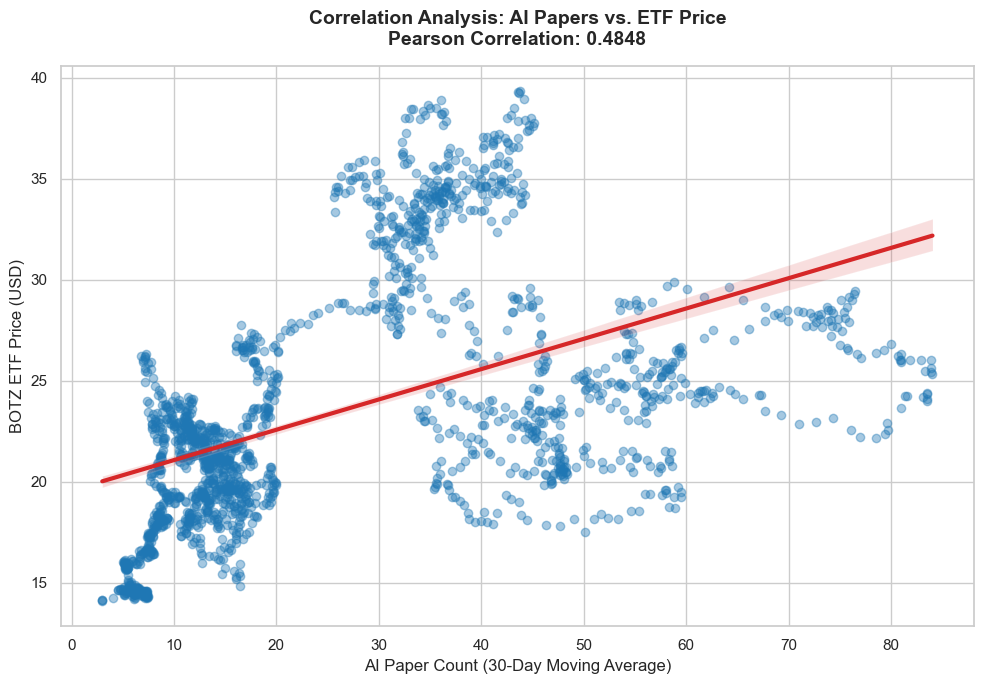

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the master dataset
df = pd.read_csv("ai_market_master_dataset.csv", parse_dates=["date"])

# Ensure 30-day MA is calculated as used in the correlation
df["paper_trend_30d"] = df["paper_count"].rolling(window=30, min_periods=1).mean()

# Visualization: Scatter Plot with Regression Line
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))

# regplot adds the regression line automatically
sns.regplot(data=df, x="paper_trend_30d", y="price", 
            scatter_kws={'alpha':0.4, 'color':'#1f77b4'}, 
            line_kws={'color':'#d62728', 'lw':3})

# Titles and Labels in English
plt.title(f"Correlation Analysis: AI Papers vs. ETF Price\nPearson Correlation: 0.4848", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("AI Paper Count (30-Day Moving Average)", fontsize=12)
plt.ylabel("BOTZ ETF Price (USD)", fontsize=12)

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
from scipy import stats

# 1. Load the data
df = pd.read_csv("ai_market_master_dataset.csv")

# 2. Calculate the trend
df["paper_trend_30d"] = df["paper_count"].rolling(window=30, min_periods=1).mean()

# Handle any NaN values that might have occurred during rolling average
# (Crucial for scipy functions to work correctly)
valid_data = df[['price', 'paper_trend_30d']].dropna()

# 3. Pearson Correlation and P-Value
pearson_coef, pearson_p = stats.pearsonr(valid_data['paper_trend_30d'], valid_data['price'])

# 4. Spearman Correlation and P-Value
spearman_coef, spearman_p = stats.spearmanr(valid_data['paper_trend_30d'], valid_data['price'])

print("--- Detailed Statistical Correlation Results ---")
print(f"Pearson Correlation: {pearson_coef:.4f}")
print(f"Pearson P-Value:     {pearson_p:.4e}") # Using scientific notation for very small values

print("-" * 40)

print(f"Spearman Correlation: {spearman_coef:.4f}")
print(f"Spearman P-Value:     {spearman_p:.4e}")

# 5. Quick Interpretation
def interpret_p(p):
    return "Significant" if p < 0.05 else "Not Significant"

print("-" * 40)
print(f"Statistical Significance (p < 0.05): {interpret_p(spearman_p)}")

--- Detailed Statistical Correlation Results ---
Pearson Correlation: 0.4848
Pearson P-Value:     7.5130e-109
----------------------------------------
Spearman Correlation: 0.6049
Spearman P-Value:     1.1290e-183
----------------------------------------
Statistical Significance (p < 0.05): Significant


In [19]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests
import warnings

# Gereksiz uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

# 1. Veriyi yükle
df = pd.read_csv("ai_market_master_dataset.csv", parse_dates=["date"])
df = df.sort_values("date").dropna()

# 2. Durağanlık için fark al (Stationarity)
df['paper_diff'] = df['paper_count'].diff().fillna(0)
data_to_test = df[['daily_return', 'paper_diff']]

# 3. Granger Testi: 30 Günlük Geniş Pencere
max_lag = 30
print(f"--- Granger Causality Analysis (Lags: 1 to {max_lag} Days) ---")
print(f"{'Lag (Day)':<12} | {'P-Value':<12} | {'Result'}")
print("-" * 40)

results = grangercausalitytests(data_to_test, maxlag=max_lag, verbose=False)

# Sadece her 5 günde bir olanları veya en önemli kırılımları yazdırarak okuyucuyu boğmuyoruz
for lag, test_results in results.items():
    # En yaygın kullanılan test olan 'ssr_chi2test' p-değerini alıyoruz
    p_val = test_results[0]['ssr_chi2test'][1]
    
    # Her gün yerine 1, 2, 5, 10, 15, 20, 25, 30. günleri gösterelim (Okunabilirlik için)
    if lag in [1, 2, 5, 10, 15, 20, 25, 30]:
        status = "SIGNIFICANT ⭐" if p_val < 0.05 else "Insignificant"
        print(f"Day {lag:<8} | {p_val:<12.4f} | {status}")

print("-" * 40)
print("Conclusion: Does academic growth DRIVE the market in the long run?")

--- Granger Causality Analysis (Lags: 1 to 30 Days) ---
Lag (Day)    | P-Value      | Result
----------------------------------------
Day 1        | 0.1288       | Insignificant
Day 2        | 0.0840       | Insignificant
Day 5        | 0.4154       | Insignificant
Day 10       | 0.3831       | Insignificant
Day 15       | 0.5803       | Insignificant
Day 20       | 0.7746       | Insignificant
Day 25       | 0.8375       | Insignificant
Day 30       | 0.7837       | Insignificant
----------------------------------------
Conclusion: Does academic growth DRIVE the market in the long run?


In [20]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests
import warnings

warnings.filterwarnings('ignore')

# 1. Veriyi hazırla
df = pd.read_csv("ai_market_master_dataset.csv", parse_dates=["date"])
df = df.sort_values("date").dropna()

# 2. Farkları al (Durağanlık için)
df['paper_diff'] = df['paper_count'].diff().fillna(0)

# --- DİKKAT: Sütun yerlerini değiştiriyoruz ---
# [Hedef: Makale Değişimi, Tahmin Edici: Borsa Getirisi]
data_reverse = df[['paper_diff', 'daily_return']]

print("--- Reverse Granger Causality: Do Market Returns Predict AI Papers? ---")
print(f"{'Lag (Day)':<12} | {'P-Value':<12} | {'Result'}")
print("-" * 40)

# 30 Günlük Pencerede Test
max_lag = 30
results_rev = grangercausalitytests(data_reverse, maxlag=max_lag, verbose=False)

for lag, test_results in results_rev.items():
    p_val = test_results[0]['ssr_chi2test'][1]
    
    if lag in [1, 2, 5, 10, 15, 20, 25, 30]:
        status = "SIGNIFICANT ⭐" if p_val < 0.05 else "Insignificant"
        print(f"Day {lag:<8} | {p_val:<12.4f} | {status}")

print("-" * 40)

--- Reverse Granger Causality: Do Market Returns Predict AI Papers? ---
Lag (Day)    | P-Value      | Result
----------------------------------------
Day 1        | 0.5067       | Insignificant
Day 2        | 0.1898       | Insignificant
Day 5        | 0.3410       | Insignificant
Day 10       | 0.4259       | Insignificant
Day 15       | 0.1413       | Insignificant
Day 20       | 0.0170       | SIGNIFICANT ⭐
Day 25       | 0.0375       | SIGNIFICANT ⭐
Day 30       | 0.0145       | SIGNIFICANT ⭐
----------------------------------------
